In [22]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pandas as pd
import re
import rasterio
import random
from rasterio.transform import from_origin
from pyproj import Transformer
import re
import scipy as sp
import pyreadr
import sys
sys.path.append(os.path.abspath('../src/'))
from utils import *
from scipy import stats
import argparse
import copy
import glob
import argparse
import cProfile
import csv
from functools import partial
import itertools
import math
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import rasterio
from scipy import stats
from scipy.optimize import minimize
# from scipy.special import binom
from skimage import graph
import sys
import time
from tqdm import tqdm
import numpy.ma as ma
import warnings
import numpy as np
import psutil
import gc

warnings.filterwarnings("ignore")

import logging
logging.getLogger("distributed").setLevel(logging.ERROR)

### Random Grid Generations

In [23]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/1000m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/traps_to_remove_1km.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_1km"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"   # ID column used for selection
trap_index_col = "Trap_index"  # Column to output in excluded files

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Save selected traps (original format)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_df.to_csv(selected_path, index=False)

        # Excluded traps — only trap_index column
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]

        excluded_only_index = excluded_df[[trap_index_col]]

        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap and excluded trap-index files generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [24]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/500m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/traps_to_remove_UTM10N_updated.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_500m"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"    # Used for filtering & selection

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps (random sample)
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Keep only the Trap_index column for selected traps
        selected_only_index = selected_df[[trap_id_col]]

        # Save selected traps as .txt (one per line, no header)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_only_index.to_csv(selected_path, index=False, header=False)

        # Excluded traps — from original grid_df
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]
        excluded_only_index = excluded_df[[trap_id_col]]

        # Save excluded traps as .txt
        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap ID .txt files (selected & excluded) generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [25]:
grid_df

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


### Forward Greedy

In [26]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG36/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG36/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:70]  # Limit to first 70 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG36/selected_traps.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('full_grid_500m/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG36/FG36-excluded_traps-70.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 70 traps
Excluded 2367 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


### Selected Traps Heat Map

In [27]:
parent_dir = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Forward Greedy'
folders = [f'FG{i}' for i in range(48, 54)]

all_data = []
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        all_data.append(df)
df_all = pd.concat(all_data, ignore_index=True)

# Count how many times each Trap_index was selected
trap_counts = df_all['Trap_index'].value_counts().reset_index()
trap_counts.columns = ['Trap_index', 'count']

# Load candidate traps (includes x, y, Prior_cam, Trap_index)
candidate_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
df_candidates = pd.read_csv(candidate_path)

# Ensure Trap_index columns are numeric and clean
df_candidates['Trap_index'] = pd.to_numeric(df_candidates['Trap_index'], errors='coerce')
trap_counts['Trap_index'] = pd.to_numeric(trap_counts['Trap_index'], errors='coerce')

df_candidates = df_candidates.dropna(subset=['Trap_index']).copy()
trap_counts = trap_counts.dropna(subset=['Trap_index']).copy()

df_candidates['Trap_index'] = df_candidates['Trap_index'].astype(int)
trap_counts['Trap_index'] = trap_counts['Trap_index'].astype(int)

# Merge candidate data (with x, y, Prior_cam) and counts on Trap_index
result = pd.merge(df_candidates, trap_counts, on='Trap_index', how='right')

# Select desired columns: coordinates come from candidates file now
result = result[['Trap_index', 'x', 'y', 'Prior_cam', 'count']]

# Save result or print preview
result.to_csv('trap_id_selection_count.csv', index=False)

result2 =result[result['Prior_cam'] == 0]
result2.to_csv('trap_id_selection_count_NEW_CAMS.csv', index=False)

In [28]:
result2

,Trap_index,x,y,Prior_cam,count
21,1041,493483.355444,5.651120e+06,0,5
22,717,521860.089284,5.640515e+06,0,5
23,128,517949.862830,5.658720e+06,0,5
24,1038,491343.699278,5.652666e+06,0,5
25,897,493720.995156,5.640971e+06,0,5
26,1382,489361.621824,5.654703e+06,0,5
76,1151,492082.054012,5.660346e+06,0,4
77,974,494935.326961,5.663344e+06,0,4
78,1189,493761.232891,5.662357e+06,0,4
79,906,495622.062750,5.642457e+06,0,3


In [29]:
# how many unique proposed layouts of traps are there? essentially, determine the unique combinations of Trap_index that appear in each of the selected_traps.csv files

# for each selected_traps.csv file, return the selected trap indices as a set, then convert the list of sets to a set of frozensets to get unique combinations
unique_combinations = set()
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        unique_combinations.add(frozenset(df['Trap_index'].unique()))
# Count the number of unique combinations
num_unique_combinations = len(unique_combinations)
print(f'Number of unique trap combinations: {num_unique_combinations}')
# # Print the unique combinations
# print(f'Unique trap combinations: {unique_combinations}')


# let me know the folder names that have each of the unique combinations
combination_to_folders = {comb: [] for comb in unique_combinations}
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        comb = frozenset(df['Trap_index'].unique())
        combination_to_folders[comb].append(folder)
# Print the folder names for each unique combination
for comb, folder_list in combination_to_folders.items():
    print(f'Combination: {comb}, Folders: {folder_list}')
# Save the unique combinations and their corresponding folders to a CSV fil


Number of unique trap combinations: 3
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1382', '1397', '1463', '1425', '1460', '1189', '1151', '1396', '1414', '1404', '1437', '1438', '1415', '1405', '1408', '1451', '1403', '1418', '1423', '1419', '128', '1429', '1465', '1424', '1411', '1038', '1401', '1412', '717', '1443', '1432', '1445', '1452', '897', '1442', '1420', '1399', '974', '1458', '1426', '1464', '1431', '1440', '1417', '1457', '1410', '1441', '1446', '1459', '1435', '1454', '1433', '1447'}), Folders: ['FG50', 'FG52']
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '67', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1

In [30]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')
# Exclude nulls and values > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

plt.figure(figsize=(10, 6))
sns.violinplot(x='Configuration', y='Absolute Error N', data=df_filtered, inner='box')
plt.yscale('log')  # Apply logarithmic scaling to y axis
plt.title('Violin Plot of Absolute Error N by Configuration (Log Scale)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N (log scale)')
plt.tight_layout()
plt.show()



NameError: name 'sns' is not defined

<Figure size 720x432 with 0 Axes>

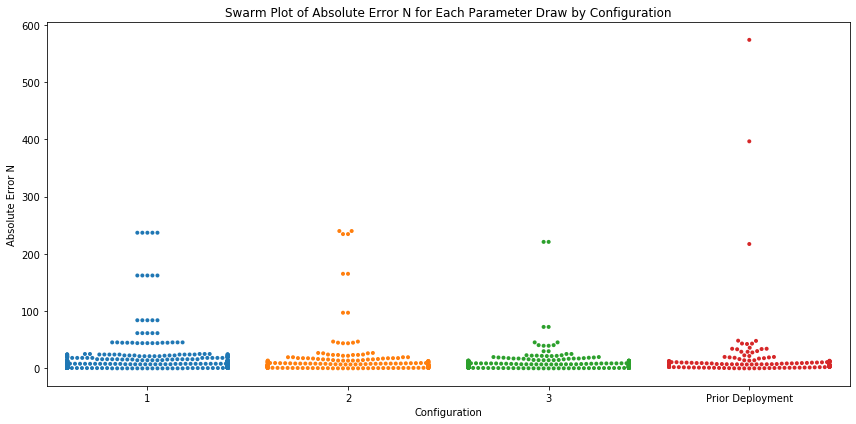

In [ ]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')

df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 1000]

df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

# Plot a swarm plot with all 150 parameter draw values per configuration
plt.figure(figsize=(12, 6))
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=4
)
plt.title('Swarm Plot of Absolute Error N for Each Parameter Draw by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()



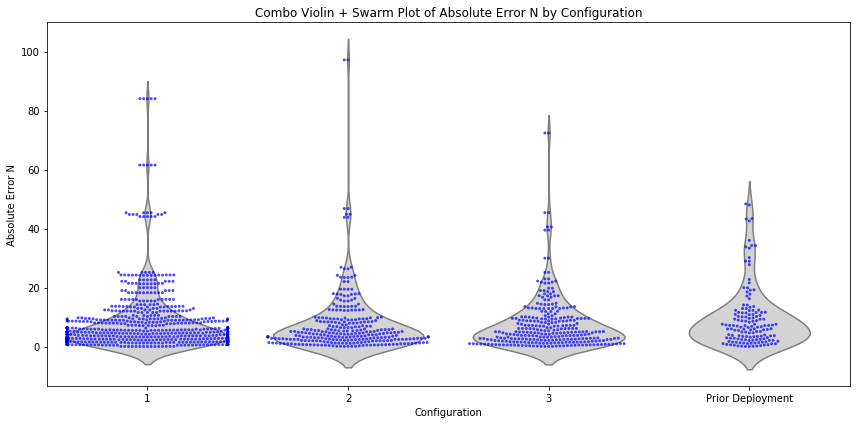

In [ ]:

# Exclude missing values and 'Absolute Error N' > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

# Convert "Configuration" to string for clear labels
df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

plt.figure(figsize=(12, 6))
# Plot the violin plot
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    inner=None,      # Hide internal marks so swarm plot is clear
    color='lightgray'
)
# Overlay the swarm plot
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Combo Violin + Swarm Plot of Absolute Error N by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


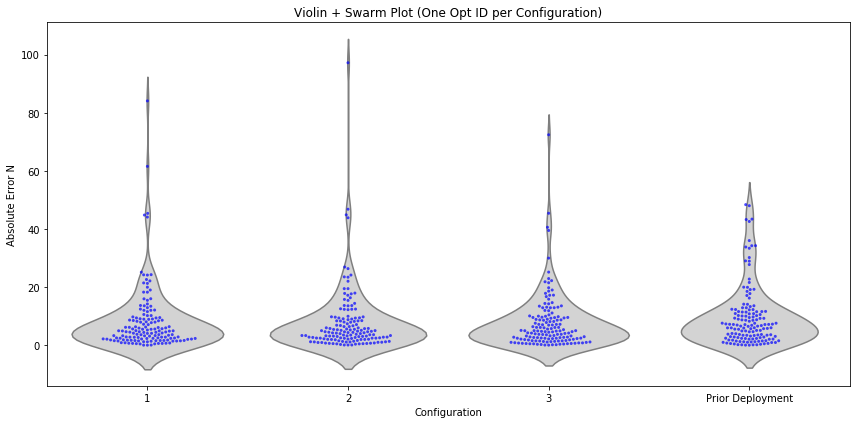

In [ ]:
# For each configuration, pick ONE opt id (here: the first opt ID encountered for each configuration)
chosen = df_filtered.groupby('Configuration')['Optimization ID'].first().reset_index()
# Filter DF to keep only those Opt IDs
filtered_one_per_config = df_filtered.merge(chosen, on=['Configuration', 'Optimization ID'])

# Plot violin+swarm using only one Opt ID per configuration
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    inner=None,
    color='lightgray'
)
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Violin + Swarm Plot (One Opt ID per Configuration)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


### Forward Greedy with Base

In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates as numpy array
coords = traps_df[['x', 'y']].to_numpy()

# Calculate the pairwise distance matrix
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs once (i < j to avoid duplicates)
unique_pairs = [
    (int(traps_df.iloc[i]['Trap_index']), int(traps_df.iloc[j]['Trap_index']))
    for i, j in zip(pairs[0], pairs[1]) if i < j
]

# Example: print the results
for pair in unique_pairs:
    print(pair)


(1, 29)
(1, 778)
(1, 779)
(1, 780)
(1, 809)
(2, 35)
(2, 36)
(2, 37)
(2, 783)
(2, 785)
(2, 808)
(3, 19)
(3, 788)
(3, 789)
(3, 790)
(3, 792)
(3, 1310)
(4, 22)
(4, 510)
(4, 511)
(4, 955)
(4, 966)
(5, 551)
(5, 552)
(5, 569)
(5, 572)
(5, 1363)
(5, 1364)
(6, 7)
(6, 350)
(6, 353)
(6, 401)
(6, 404)
(6, 1354)
(7, 8)
(7, 350)
(7, 351)
(7, 353)
(7, 354)
(8, 351)
(8, 352)
(8, 354)
(8, 712)
(9, 27)
(9, 522)
(9, 523)
(9, 524)
(9, 960)
(10, 11)
(10, 494)
(11, 422)
(12, 568)
(12, 570)
(12, 571)
(12, 573)
(12, 575)
(12, 576)
(12, 1028)
(12, 1029)
(12, 1364)
(12, 1365)
(13, 14)
(13, 421)
(13, 422)
(13, 427)
(13, 429)
(14, 421)
(14, 502)
(14, 503)
(15, 16)
(15, 498)
(15, 500)
(15, 501)
(15, 502)
(15, 503)
(15, 574)
(15, 579)
(15, 1366)
(16, 17)
(16, 502)
(16, 503)
(16, 504)
(17, 502)
(17, 503)
(17, 504)
(18, 625)
(18, 972)
(18, 1308)
(19, 611)
(19, 789)
(19, 790)
(19, 792)
(19, 1310)
(20, 21)
(20, 611)
(20, 612)
(20, 789)
(20, 792)
(20, 793)
(20, 1309)
(21, 611)
(21, 612)
(21, 789)
(21, 792)
(21, 793)
(2

In [ ]:
print(len(unique_pairs), "pairs found within 500m distance.")

3392 pairs found within 500m distance.


In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates and indices
coords = traps_df[['x', 'y']].to_numpy()
trap_indices = traps_df['Trap_index'].to_numpy()

# Calculate pairwise distances
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs with i < j to avoid duplicates
unique_pairs = [(i, j) for i, j in zip(pairs[0], pairs[1]) if i < j]

# Track cameras to remove (we will remove the second camera in each pair)
to_remove_indices = set(j for i, j in unique_pairs)

# Alternative: if you want a deterministic removal to avoid removing multiple times,
# you can also do a greedy approach removing cameras, but the above is simplest

# Indices of cameras to keep
all_indices = set(range(len(traps_df)))
to_keep_indices = all_indices - to_remove_indices

# Filter original dataframe by kept indices
remaining_cameras = traps_df.iloc[list(to_keep_indices)]

print(f"Number of cameras before removal: {len(traps_df)}")
print(f"Number of cameras after removal: {len(remaining_cameras)}")

# Optional: Save remaining cameras to a new CSV
# remaining_cameras.to_csv('remaining_cameras.csv', index=False)


Number of cameras before removal: 1465
Number of cameras after removal: 288


In [ ]:
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')
ac_coords = ac_coords[None]
ac_coords_list = ac_coords[['x', 'y']].values.tolist()
ac_coords_list = np.array(ac_coords_list)
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [ ]:
# what x,y coords in scrpy/pgaff-testing/secr/Prior Deployment/deployed_cams_2024.csv are not in the scrpy/pgaff-testing/only_trail/500m/trail_candidate_traps_spacing500.csv?

deployed_cams = pd.read_csv('./secr/Prior Deployment/P1/deployed_cams_2024.csv')
deployed_cams_coords = deployed_cams[['x', 'y']].values.tolist()
deployed_cams_coords = np.array(deployed_cams_coords)

candidate_cams = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv')
candidate_cams_coords = candidate_cams[['x', 'y']].values.tolist()
candidate_cams_coords = np.array(candidate_cams_coords)
# Find the coordinates in deployed_cams_coords that are not in candidate_cams_coords
missing_coords = []
for coord in deployed_cams_coords:
    if not any(np.array_equal(coord, candidate_coord) for candidate_coord in candidate_cams_coords):
        missing_coords.append(coord)
missing_coords = np.array(missing_coords)
print(len(missing_coords))


68


In [ ]:
true_n = pd.read_csv('./only_trail_1km/True_N_per_draw.csv')
# valid_ids = true_n['Parameter_draw'].tolist()                               # Change this if you want to filter with parameter draws in between some values of N or g0

params = pd.read_csv('./only_trail_1km/param_values_for_each_draw150.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})
params = params.sample(n=50).reset_index(drop=True)                          # Randomly select 5 draws
# params = params[params['index'].isin(valid_ids)].iloc[:5]
print(f"Using {params['index'].tolist()} parameter draws")

D, g0, sigma = params['D'].values, params['g0'].values, params['sigma'].values
draw = params['index'].tolist()
draw_to_trueN = dict(zip(true_n['Parameter_draw'], true_n['N']))

# Gather all potential activity center locations
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')[None]
ac_coords_list = ac_coords[['x', 'y']].values

# Load full possible trap grid
full_trap_grid = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv').drop(columns=['Unnamed: 0'])
full_trap_grid = full_trap_grid.rename(columns={'X': 'x', 'Y': 'y'})

# Candidate traps after 50m accessibility filter
# excluded_ids = pd.read_csv('./500m_data/traps_to_remove_50m.csv')['TrapID']
# candidate_grid = full_trap_grid[~full_trap_grid['Trap_index'].isin(excluded_ids)].copy()
candidate_grid = full_trap_grid.copy()

# Load all 68 deployed traps
# deployed_df = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')
# deployed_df = deployed_df[['x', 'y', 'Trap_index']]  # assuming correct format from file
deployed_df = full_trap_grid[full_trap_grid['Prior_cam']==1].copy()
deployed_df

candidate_exclusive = candidate_grid[~candidate_grid['Trap_index'].isin(deployed_df['Trap_index'])][['x', 'y', 'Trap_index']]

candidate_exclusive

Using [4, 9, 18, 61, 107, 45, 95, 24, 49, 58, 106, 33, 131, 139, 40, 97, 85, 37, 80, 71, 109, 133, 31, 117, 146, 51, 67, 87, 65, 11, 89, 14, 122, 98, 137, 144, 26, 42, 62, 147, 53, 74, 88, 83, 8, 15, 141, 56, 66, 119] parameter draws


,x,y,Trap_index
0,510670.337539,5.634173e+06,1
1,510589.866136,5.636167e+06,2
2,511461.885975,5.637240e+06,3
3,516098.336526,5.638313e+06,4
4,514871.344999,5.641862e+06,5
...,...,...,...
1390,502867.143885,5.653349e+06,1391
1391,502779.344158,5.652899e+06,1392
1392,514477.896293,5.639606e+06,1393
1393,514898.265452,5.639352e+06,1394


### File Manipulation

In [ ]:
# Paths
base_dir = './secr/Forward Greedy/FG54'
trap_coords_list = pd.read_csv(f'{base_dir}/considered_trap_locs.csv')
selected_traps = np.load(f'{base_dir}/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# All trap coordinates (full grid)
trap_coords = pd.read_csv('full_grid_500m/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

all_trap_ids = set(trap_coords['Trap_index'])

# Make sure output directory exists
os.makedirs(base_dir, exist_ok=True)

# Loop over trap counts
for n_cams in [10, 20, 30, 40, 50, 60, 70, 80]:
    # Take the first `n_cams` traps
    traps_subset = selected_traps[:n_cams]

    # Subset trap coords by those traps
    trap_coords_list_sub_df = trap_coords_list.iloc[traps_subset].copy()
    trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Match SECR spec

    # Save selected traps CSV
    trap_csv_path = f'{base_dir}/selected_traps_{n_cams}.csv'
    trap_coords_list_sub_df.to_csv(trap_csv_path, index=True)

    # Determine excluded trap IDs
    selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])
    excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

    # Save excluded IDs as TXT
    excluded_txt_path = f'{base_dir}/FG55-excluded_traps-{n_cams}.txt'
    with open(excluded_txt_path, 'w') as f:
        for item in excluded_trap_ids:
            f.write("%s\n" % item)

    print(f"[{n_cams} cams] Selected {len(traps_subset)} traps, "
          f"Excluded {len(excluded_trap_ids)} traps, "
          f"Total traps in full grid: {len(all_trap_ids)}")
    print(f"   Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} = {len(all_trap_ids)}")


In [ ]:
# put the Traps IDs that have a Prior_cam value of 0 into the txt file based on the data in scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv

# File paths
input_csv = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv"
output_txt = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt"

# Change these variables if your columns have different names
trap_id_column = 'Trap_index'     # Replace with the actual Trap ID column name
prior_cam_column = 'Prior_cam' # Replace with the actual Prior_cam column name

trap_ids = []

# Read the CSV and extract Trap IDs
with open(input_csv, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if row[prior_cam_column] == '0' or row[prior_cam_column] == 0:
            trap_ids.append(row[trap_id_column])

# Write Trap IDs to a txt file
with open(output_txt, 'w', encoding='utf-8') as txtfile:
    for trap_id in trap_ids:
        txtfile.write(f"{trap_id}\n")

print(f"Extracted {len(trap_ids)} Trap IDs to '{output_txt}'.")


Extracted 1395 Trap IDs to '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt'.


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG11/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 20:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 20 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG11/selected_traps-20.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG11/BG11-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# find the lat longs in scrpy/pgaff-testing/500m_data/SCM_deployed_cams_2024.csv that are not in 500m_trap_grid.csv
deployed_cams = pd.read_csv('deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})
# merge with trap_coords to find the traps that are not in the grid
deployed_cams = deployed_cams.merge(trap_coords, on=['x', 'y'], how='left')

In [ ]:
deployed_cams

,Unnamed: 0,TrapID,x,y,Trap_index
0,1,2428,491737.787215,5.663510e+06,2428
1,2,1604,490737.787215,5.653510e+06,1604
2,3,1720,491737.787215,5.654510e+06,1720
3,4,1426,492237.787215,5.652010e+06,1426
4,5,2422,496237.787215,5.663010e+06,2422
...,...,...,...,...,...
63,64,1362,518237.787215,5.651010e+06,1362
64,65,1047,518737.787215,5.648010e+06,1047
65,66,680,518237.787215,5.644510e+06,680
66,67,474,518237.787215,5.642510e+06,474


In [ ]:
deployed_cams.to_csv('secr/Prior Deployment/deployed_cams_2024.csv', index=False)

In [ ]:
# Load the deployed cameras file and rename coordinate columns for consistency
deployed_cams = pd.read_csv('500m_data/SCM_deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})

# Load the full trap grid
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')

# Identify grid records (by x,y) that are not present in deployed cameras
not_in_deployed = trap_coords[
    ~trap_coords[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]

not_in_deployed

not_in_deployed['Trap_index'].to_csv('not_in_2019_deployment.txt', index=False, header=False)


# with open('secr/2019 Deployment/deployed_cams_not_in_grid.txt', 'w') as f:
#     for item in deployed_cams_not_in_grid['TrapID']:
#         f.write("%s\n" % item)

In [ ]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [ ]:
deployed_cams

,Unnamed: 0,TrapID,x,y
0,1,2428,491737.787215,5.663510e+06
1,2,1604,490737.787215,5.653510e+06
2,3,1720,491737.787215,5.654510e+06
3,4,1426,492237.787215,5.652010e+06
4,5,2422,496237.787215,5.663010e+06
...,...,...,...,...
63,64,1362,518237.787215,5.651010e+06
64,65,1047,518737.787215,5.648010e+06
65,66,680,518237.787215,5.644510e+06
66,67,474,518237.787215,5.642510e+06


In [ ]:
trap_coords

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
# selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:

# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:68]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-68.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
trap_coords = pd.read_csv('./500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['TrapID'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")

trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])
trap_coords_list_df.to_csv('./secr/Random/R3/considered_trap_locs.csv', index=False)

# randomly select 68 of the trap locations
selected_traps = np.random.choice(trap_coords_list.shape[0], size=68, replace=False)
trap_coords_list_sub_df = trap_coords_list_df.iloc[selected_traps]


# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Random/R3/selected_traps.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Random/R3/R3-excluded_traps.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

(258, 2) candidate trap locations
Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
exclude_trap_coords

,TrapID,X,Y
0,1,509737.787215,5.633510e+06
1,2,510237.787215,5.633510e+06
2,3,510737.787215,5.633510e+06
3,4,511237.787215,5.633510e+06
4,5,509237.787215,5.634010e+06
...,...,...,...
2174,2433,496737.787215,5.663510e+06
2175,2434,489737.787215,5.664010e+06
2176,2435,490237.787215,5.664010e+06
2177,2436,490737.787215,5.664010e+06


### Costing Surfaces

In [ ]:
traps = pd.read_csv('./500m_data/500m_trap_grid.csv')
deployed_cams = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')

# Identify traps that are not in deployed_cams
not_in_deployed = traps[
    ~traps[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]
not_in_deployed

not_in_deployed.to_csv('traps_to_remove_prior.csv')

In [ ]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 500
costing_surface_allowed = costing_surface[~(costing_surface['rel_cost'].isna()) & ~(costing_surface['Distance_to_trail_m'] > 500.00)]
costing_surface_allowed

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
60,61,61,431.303809,916.542688,0.081414,508737.7872,5637010.469
61,62,62,361.697779,861.470553,0.076522,509237.7872,5637010.469
62,63,63,376.082558,818.130720,0.072672,509737.7872,5637010.469
63,64,64,370.426454,864.657365,0.076805,510237.7872,5637010.469
65,66,66,441.168219,877.416023,0.077938,511237.7872,5637010.469
...,...,...,...,...,...,...,...
2428,2429,2429,248.762323,3529.317834,0.313499,494737.7872,5663510.469
2429,2430,2430,116.778259,3468.382344,0.308086,495237.7872,5663510.469
2430,2431,2431,25.001649,3496.168778,0.310554,495737.7872,5663510.469
2431,2432,2432,252.564797,3635.222101,0.322906,496237.7872,5663510.469


In [ ]:
# from selected_traps.csv in FG11, return a csv that has just the x,y coordinates of those that are not in deployed_cams_2024.csv
selected_traps = pd.read_csv('secr/Forward Greedy/FG11/selected_traps-20.csv')


In [ ]:
# Step 1: Combine all x,y coordinates from AC_locations into one DataFrame
ac_files = glob.glob('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/AC_locations/*.csv')
ac_coords = []

for file in ac_files:
    df = pd.read_csv(file)
    if 'x' in df.columns and 'y' in df.columns:
        ac_coords.append(df[['x', 'y']])

# Concatenate all the coordinate DataFrames
ac_coords_df = pd.concat(ac_coords, ignore_index=True)

# Save to a single CSV file
# combined_path = '7-21 data/AC_locations/combined_ac_coords.csv'
ac_coords_df.to_csv('combined_ac_coords.csv', index=False)
print(f"Combined coordinates saved")

Combined coordinates saved


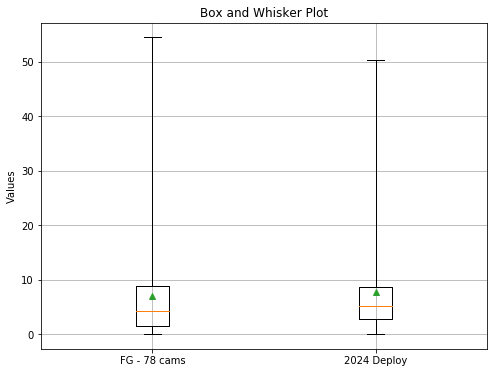

In [ ]:
import matplotlib.pyplot as plt

# Summary statistics
labels = ['FG - 78 cams', '2024 Deploy']
min_vals = [0.049, 0.026]
q1 = [1.54, 2.72]
median = [4.22, 5.08]
q3 = [8.77, 8.58]
max_vals = [54.47, 50.25]
means = [6.97, 7.76]

# Prepare boxplot data for matplotlib's bxp() function
box_data = []
for i in range(len(labels)):
    box_data.append({
        'label': labels[i],
        'whislo': min_vals[i],     # Lower whisker (min)
        'q1': q1[i],               # First quartile (Q1)
        'med': median[i],          # Median (Q2)
        'q3': q3[i],               # Third quartile (Q3)
        'whishi': max_vals[i],     # Upper whisker (max)
        'mean': means[i],          # Mean (optional)
        'fliers': []               # No outliers available
    })

# Create the box and whisker plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bxp(box_data, showmeans=True)
ax.set_ylabel('Values')
ax.set_title('Box and Whisker Plot')
ax.grid(True)
plt.show()


In [ ]:
# add the data from all the files in AC_locations into a singular csv file.


In [ ]:
costing_surface_disallowed = costing_surface[(costing_surface['rel_cost'].isna()) | (costing_surface['Distance_to_trail_m'] > 500.00)]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['Trap_index', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_cost_500m.csv', index=False)

In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 50
costing_surface_allowed = costing_surface[~(costing_surface['Rel_cost'].isna())]
costing_surface_allowed


costing_surface_disallowed = costing_surface[(costing_surface['Rel_cost'].isna())]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['TrapID', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_50m.csv', index=False)

In [ ]:
costing_surface

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
0,1,1,3842.015535,NaN,NaN,509737.7872,5633510.469
1,2,2,3855.952509,NaN,NaN,510237.7872,5633510.469
2,3,3,3874.371793,NaN,NaN,510737.7872,5633510.469
3,4,4,3822.221227,NaN,NaN,511237.7872,5633510.469
4,5,5,3355.109326,NaN,NaN,509237.7872,5634010.469
...,...,...,...,...,...,...,...
2432,2433,2433,171.146726,3789.301023,0.336592,496737.7872,5663510.469
2433,2434,2434,4130.440150,NaN,NaN,489737.7872,5664010.469
2434,2435,2435,3668.201922,NaN,NaN,490237.7872,5664010.469
2435,2436,2436,3217.277553,NaN,NaN,490737.7872,5664010.469


In [ ]:
import numpy as np

def average_diff_and_abs_diff_for_iteration(file_path, iteration_num):
    """
    Returns both the average error (Diff, signed)
    and the average absolute error (|Diff|) for the given iteration.
    """
    diffs = []
    with open(file_path, 'r') as f:
        found_iter = False
        target_iter_line = f"Iteration {iteration_num}:"
        for line in f:
            if line.strip().startswith(target_iter_line):
                found_iter = True
                continue
            if found_iter:
                if line.strip().startswith('Iteration'):
                    # Reached next iteration, stop reading further
                    break
                if 'Diff=' in line:
                    try:
                        diff_value = float(line.split('Diff=')[1].strip())
                        diffs.append(diff_value)
                    except ValueError:
                        continue
    if not diffs:
        print(f"No 'Diff' values found for iteration {iteration_num}.")
        return None, None
    average_error = np.mean(diffs)
    average_abs_error = np.mean(np.abs(diffs))
    print(f"Average Error for iteration {iteration_num}: {average_error}")
    print(f"Average Absolute Error for iteration {iteration_num}: {average_abs_error}")
    return average_error, average_abs_error

# Example usage:
file_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Backward Greedy/BG8/n_tracker.txt'
iteration_num = 238  # Change to desired iteration
average_diff_and_abs_diff_for_iteration(file_path, iteration_num)


Average Error for iteration 238: -32.418700740400105
Average Absolute Error for iteration 238: 32.418700740400105


(-32.418700740400105, 32.418700740400105)

In [ ]:
# In each capture history file, determine what individuals and how many were observed.
def get_individuals(capture_history_file):
    """
    Return the unique number of individuals in the 'individual' column
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individuals = set()
        for row in reader:
            individual = row['individual']
            individuals.add(individual)
    return individuals

def get_recaptures(capture_history_file):
    """
    Return the number of individuals that have been captured more than once.
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individual_counts = {}
        for row in reader:
            individual = row['individual']
            if individual in individual_counts:
                individual_counts[individual] += 1
            else:
                individual_counts[individual] = 1
        # Count individuals with more than one capture
        recaptures = sum(1 for count in individual_counts.values() if count > 1)
    return recaptures


def get_spatial_recaptures(capture_history_file):
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)        
        individual_locations = {}
        for row in reader:
            indv = row['individual']
            loc = (row['trap_id'])
            if indv not in individual_locations:
                individual_locations[indv] = set()
            individual_locations[indv].add(loc)
        
        # Count individuals with >1 unique location
        return sum(1 for locs in individual_locations.values() if len(locs) > 1)


# run for all the files in pgaff-testing/500m_data/capture_history/
def process_capture_history_files(directory):
    """
    Process all capture history files in the given directory.
    """
    results = []
    for filename in tqdm(os.listdir(directory)):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            individuals = get_individuals(file_path)
            recaptures = get_recaptures(file_path)
            spatial_recaptures = get_spatial_recaptures(file_path)
            results.append({
                'file': filename,
                'individuals': len(individuals),
                'recaptures': recaptures,
                'spatial_recaptures': spatial_recaptures           
                })
    # return results as a dataframe with the number at the end of the cpature history file then the unique individuals detected in the other column
    results_df = pd.DataFrame(results)
    results_df['capture_history'] = results_df['file'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else None)
    # convert both columsn to integers
    results_df['capture_history'] = results_df['capture_history'].astype(int)
    results_df = results_df[['capture_history', 'individuals', 'recaptures', 'spatial_recaptures']]
    results_df['observations'] = results_df['individuals'].astype(int)
    results_df['recaptures'] = results_df['recaptures'].astype(int)
    results_df['spatial_recaptures'] = results_df['spatial_recaptures'].astype(int)
    results_df = results_df.sort_values(by='capture_history')
    results_df.reset_index(drop=True, inplace=True)
    # Save the results to a CSV file
    output_file = os.path.join(directory, 'individuals_observed.csv')
    results_df.to_csv(output_file, index=False)
    return results_df

process_capture_history_files('only_trail_1km/500m/ch')  # Adjust the path as needed

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:03<00:00, 40.51it/s]


,capture_history,individuals,recaptures,spatial_recaptures,observations
0,1,49,41,41,49
1,2,22,18,18,22
2,3,51,51,51,51
3,4,80,75,75,80
4,5,23,17,17,23
...,...,...,...,...,...
145,146,45,39,39,45
146,147,77,70,70,77
147,148,20,18,17,20
148,149,34,30,30,34


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG3/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG3/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG3/selected_traps_20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG3/FG3-excluded_traps_20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG8/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 68:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 68 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG8/selected_traps-68.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG8/BG8-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


### Graphics for Papper

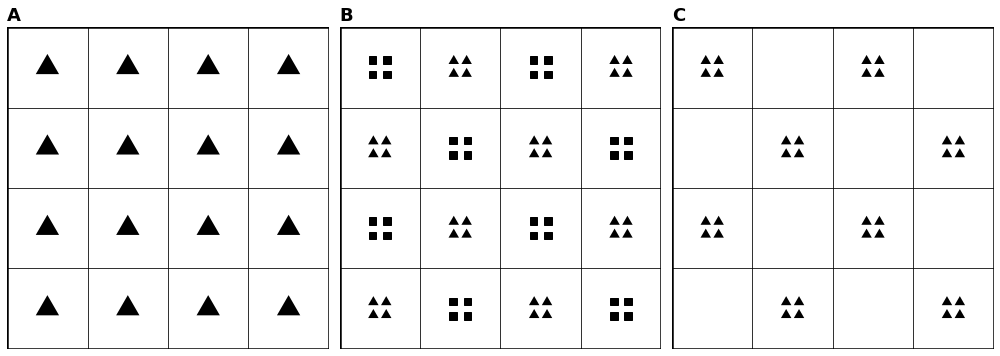

In [ ]:
def draw_triangle(ax, x_center, y_center, size=0.16):
    h = size * np.sqrt(3) / 2
    triangle = np.array([
        [x_center - size/2, y_center - h/3],
        [x_center + size/2, y_center - h/3],
        [x_center, y_center + 2*h/3]
    ])
    ax.fill(triangle[:, 0], triangle[:, 1], 'k')

def draw_2x2_triangles(ax, x_center, y_center, size=0.13, gap=0.06):
    # Draw a 2x2 grid of triangles centered at (x_center, y_center)
    offset = size / 1.3 + gap
    for dx in [-0.5, 0.5]:
        for dy in [-0.5, 0.5]:
            draw_triangle(ax,
                x_center + dx*offset,
                y_center + dy*offset,
                size)

def draw_window(ax, x_center, y_center, size=0.19):
    offset = size/2.1
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            ax.add_patch(
                patches.Rectangle(
                    (x_center + dx*offset - size/4, y_center + dy*offset - size/4),
                    size/2, size/2, color='k'
                )
            )

def make_grid(ax, n, border=0.13):
    ax.set_xlim(-border, n-1+border)
    ax.set_ylim(-border, n-1+border)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(-0.5, n, 1))
    ax.set_yticks(np.arange(-0.5, n, 1))
    ax.grid(True, which='both', color='black', linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    rec = patches.Rectangle((-0.5,-0.5), width=n, height=n,
                            linewidth=2.5, edgecolor='black',
                            facecolor='none')
    ax.add_patch(rec)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)

def plot_first_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_window(ax, j, n-1-i)
            else:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_second_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_third_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            draw_triangle(ax, j, n-1-i, size=0.29)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
plot_first_chart(axs[1])    # Chart A
plot_second_chart(axs[2])   # Chart B
plot_third_chart(axs[0])    # Chart C

# Add bold labels above each chart
labels = ['A', 'B', 'C']
for i, ax in enumerate(axs):
    ax.text(-0.5, 3.75, labels[i], fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('triangle_charts.png', dpi=300, bbox_inches='tight')
plt.show()


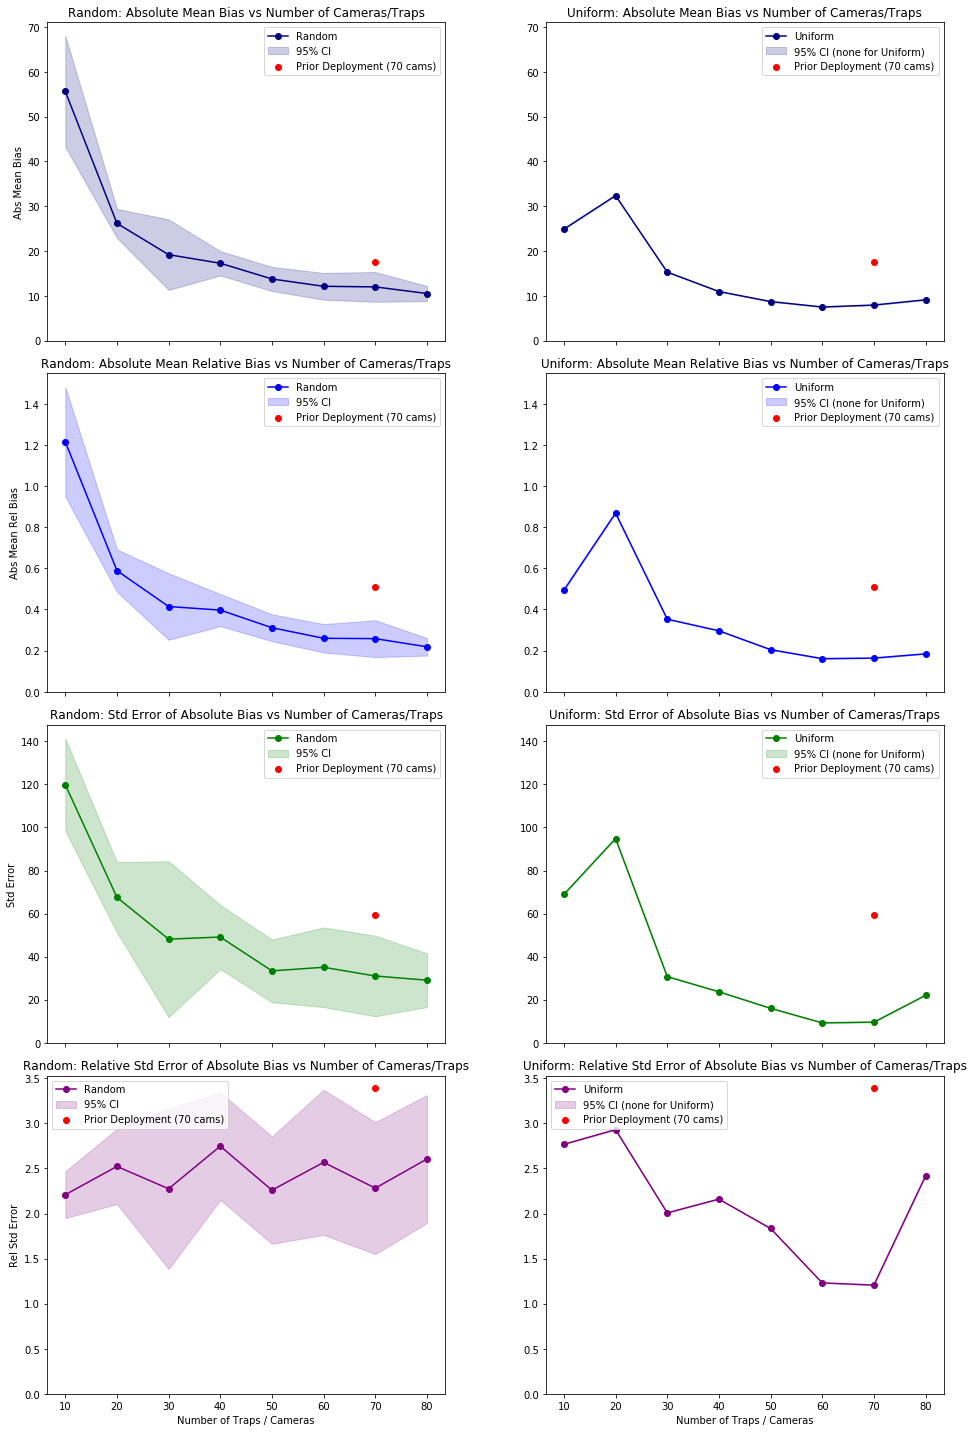

In [ ]:
######## 500 meter code
random_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_500m/results'
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/500m_fullgrid'

trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    n = len(values)
    if n > 1:
        mean_val = np.mean(values)
        sem = np.std(values, ddof=1) / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci = t_crit * sem
        return mean_val, ci
    elif n == 1:
        return values[0], 0
    else:
        return None, 0

def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    se = abs_diff.std(ddof=1)
    rse = se / mean_bias if mean_bias != 0 else np.nan
    return mean_bias, mean_rel_bias, se, rse

def process_random_data():
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        pattern = f'Random_{n_traps}traps_*_1-150.csv'
        file_paths = glob.glob(os.path.join(random_folder, pattern))
        bvals, rbvals, sevals, rsevals = [], [], [], []
        for path in file_paths:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0: continue
            mb, mrb, se, rse = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
            sevals.append(se)
            rsevals.append(rse)
        mb_mean, mb_ci = calc_95ci(bvals)
        mrb_mean, mrb_ci = calc_95ci(rbvals)
        se_mean, se_ci = calc_95ci(sevals)
        rse_mean, rse_ci = calc_95ci(rsevals)
        mean_biases.append(mb_mean)
        mean_bias_cis.append(mb_ci)
        mean_rel_biases.append(mrb_mean)
        mean_rel_bias_cis.append(mrb_ci)
        ses.append(se_mean)
        se_cis.append(se_ci)
        rses.append(rse_mean)
        rse_cis.append(rse_ci)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

def process_uniform_data():
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        fname = f'U_{n_traps}A_1-150.csv'
        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        mb, mrb, se, rse = compute_metrics(df_filtered)
        mean_biases.append(mb)
        mean_bias_cis.append(0)
        mean_rel_biases.append(mrb)
        mean_rel_bias_cis.append(0)
        ses.append(se)
        se_cis.append(0)
        rses.append(rse)
        rse_cis.append(0)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

random_results = process_random_data()
uniform_results = process_uniform_data()

prior_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/results/Prior_70cams_1-150.csv'
df_prior = pd.read_csv(prior_path)
df_prior_filtered = df_prior[df_prior['N_abs_error'] <= 1000]
prior_bias, prior_rel_bias, prior_se, prior_rse = compute_metrics(df_prior_filtered)
prior_values = [prior_bias, prior_rel_bias, prior_se, prior_rse]

trap_counts_np = np.array(trap_counts)
fig, axs = plt.subplots(4, 2, figsize=(14, 20), sharex='col')
titles = [
    'Absolute Mean Bias',
    'Absolute Mean Relative Bias',
    'Std Error of Absolute Bias',
    'Relative Std Error of Absolute Bias'
]
ylabels = ['Abs Mean Bias', 'Abs Mean Rel Bias', 'Std Error', 'Rel Std Error']
colors = ['navy', 'blue', 'green', 'purple']

for i in range(4):
    # Left: Random
    axs[i,0].plot(trap_counts_np, random_results[i*2], marker='o', color=colors[i], label='Random')
    axs[i,0].fill_between(trap_counts_np,
                          np.maximum(random_results[i*2] - random_results[i*2+1], 0),
                          random_results[i*2] + random_results[i*2+1],
                          color=colors[i], alpha=0.2, label='95% CI')
    axs[i,0].scatter(70, prior_values[i], color='red', label='Prior Deployment (70 cams)', zorder=5)
    axs[i,0].set_title(f'Random: {titles[i]} vs Number of Cameras/Traps')
    axs[i,0].set_ylabel(ylabels[i])
    axs[i,0].legend()
    axs[i,0].grid(False)
    axs[i,0].set_ylim(bottom=0)   # Force y axis to start at zero

    # Right: Uniform
    axs[i,1].plot(trap_counts_np, uniform_results[i*2], marker='o', color=colors[i], label='Uniform')
    axs[i,1].fill_between(trap_counts_np,
                          np.maximum(uniform_results[i*2] - uniform_results[i*2+1], 0),
                          uniform_results[i*2] + uniform_results[i*2+1],
                          color=colors[i], alpha=0.2, label='95% CI (none for Uniform)')
    axs[i,1].scatter(70, prior_values[i], color='red', label='Prior Deployment (70 cams)', zorder=5)
    axs[i,1].set_title(f'Uniform: {titles[i]} vs Number of Cameras/Traps')
    axs[i,1].legend()
    axs[i,1].grid(False)
    axs[i,1].set_ylim(bottom=0)   # Force y axis to start at zero

    # Synchronize y-axis upper limit as before
    ymin_l, ymax_l = axs[i,0].get_ylim()
    ymin_r, ymax_r = axs[i,1].get_ylim()
    ymax = max(ymax_l, ymax_r)
    axs[i,0].set_ylim(0, ymax)
    axs[i,1].set_ylim(0, ymax)

axs[-1,0].set_xlabel('Number of Traps / Cameras')
axs[-1,1].set_xlabel('Number of Traps / Cameras')
plt.tight_layout()
plt.show()


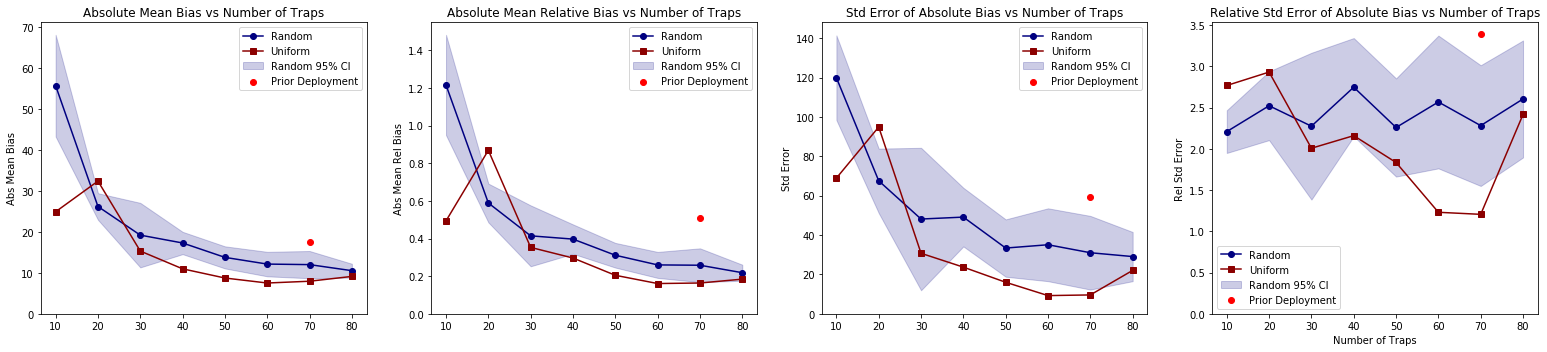

In [ ]:
############# 1km grid

random_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_500m/results'
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/500m_fullgrid'

# Base folder for Forward Greedy (FG) results
# fg_base_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Forward Greedy'

trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    n = len(values)
    if n > 1:
        mean_val = np.mean(values)
        sem = np.std(values, ddof=1) / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci = t_crit * sem
        return mean_val, ci
    elif n == 1:
        return values[0], 0
    else:
        return np.nan, 0

def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    se = abs_diff.std(ddof=1)
    rse = se / mean_bias if mean_bias != 0 else np.nan
    return mean_bias, mean_rel_bias, se, rse

def process_random_data():
    # unchanged from your code ...
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        # pattern = f'Random_1km_{n_traps}traps_*_1-150.csv'
        pattern = f'Random_{n_traps}traps_*_1-150.csv'
        file_paths = glob.glob(os.path.join(random_folder, pattern))
        bvals, rbvals, sevals, rsevals = [], [], [], []
        for path in file_paths:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0: continue
            mb, mrb, se, rse = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
            sevals.append(se)
            rsevals.append(rse)
        mb_mean, mb_ci = calc_95ci(bvals)
        mrb_mean, mrb_ci = calc_95ci(rbvals)
        se_mean, se_ci = calc_95ci(sevals)
        rse_mean, rse_ci = calc_95ci(rsevals)
        mean_biases.append(mb_mean)
        mean_bias_cis.append(mb_ci)
        mean_rel_biases.append(mrb_mean)
        mean_rel_bias_cis.append(mrb_ci)
        ses.append(se_mean)
        se_cis.append(se_ci)
        rses.append(rse_mean)
        rse_cis.append(rse_ci)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

def process_uniform_data():
    # unchanged from your code ...
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        # fname = f'U_{n_traps}A_1km_1-150.csv'
        fname = f'U_{n_traps}A_1-150.csv'

        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        mb, mrb, se, rse = compute_metrics(df_filtered)
        mean_biases.append(mb)
        mean_bias_cis.append(0)
        mean_rel_biases.append(mrb)
        mean_rel_bias_cis.append(0)
        ses.append(se)
        se_cis.append(0)
        rses.append(rse)
        rse_cis.append(0)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

# def process_fg_group(fg_folders):
#     """Process multiple FG folders as a group for each trap count.
#     Return metrics arrays similar to random/uniform but aggregated across folders.
#     """
#     mean_biases, mean_bias_cis = [], []
#     mean_rel_biases, mean_rel_bias_cis = [], []
#     ses, se_cis = [], []
#     rses, rse_cis = [], []

#     for n_traps in trap_counts:
#         # Collect all results across all folders for current n_traps
#         all_mb, all_mrb, all_se, all_rse = [], [], [], []

#         for folder in fg_folders:
#             folder_path = os.path.join(fg_base_folder, folder, 'results')
#             fname = f'{folder}_{n_traps}traps_1-150.csv'
#             fpath = os.path.join(folder_path, fname)
#             if not os.path.exists(fpath):
#                 continue
#             df = pd.read_csv(fpath)
#             df_filtered = df[df['N_abs_error'] <= 1000]
#             if len(df_filtered) == 0:
#                 continue
#             mb, mrb, se, rse = compute_metrics(df_filtered)
#             all_mb.append(mb)
#             all_mrb.append(mrb)
#             all_se.append(se)
#             all_rse.append(rse)

#         # Calculate mean and 95% CI across the collected folder results
#         mb_mean, mb_ci = calc_95ci(all_mb)
#         mrb_mean, mrb_ci = calc_95ci(all_mrb)
#         se_mean, se_ci = calc_95ci(all_se)
#         rse_mean, rse_ci = calc_95ci(all_rse)

#         mean_biases.append(mb_mean)
#         mean_bias_cis.append(mb_ci)
#         mean_rel_biases.append(mrb_mean)
#         mean_rel_bias_cis.append(mrb_ci)
#         ses.append(se_mean)
#         se_cis.append(se_ci)
#         rses.append(rse_mean)
#         rse_cis.append(rse_ci)

#     return (
#         np.array(mean_biases), np.array(mean_bias_cis),
#         np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
#         np.array(ses), np.array(se_cis),
#         np.array(rses), np.array(rse_cis)
    # )

random_results = process_random_data()
uniform_results = process_uniform_data()

# # FG folders groups
# fg5_folders = ['FG54', 'FG54-1', 'FG54-3']
# fg25_folders = ['FG55', 'FG55-2', 'FG55-3']
# fg50_folders = ['FG56', 'FG56-2', 'FG56-3']

# fg5_results = process_fg_group(fg5_folders)
# fg25_results = process_fg_group(fg25_folders)
# fg50_results = process_fg_group(fg50_folders)

prior_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/results/Prior_70cams_1-150.csv'
df_prior = pd.read_csv(prior_path)
df_prior_filtered = df_prior[df_prior['N_abs_error'] <= 1000]
prior_bias, prior_rel_bias, prior_se, prior_rse = compute_metrics(df_prior_filtered)
prior_values = [prior_bias, prior_rel_bias, prior_se, prior_rse]

trap_counts_np = np.array(trap_counts)
fig, axs = plt.subplots(1, 4, figsize=(22, 5), sharex='col')
titles = [
    'Absolute Mean Bias',
    'Absolute Mean Relative Bias',
    'Std Error of Absolute Bias',
    'Relative Std Error of Absolute Bias'
]
ylabels = ['Abs Mean Bias', 'Abs Mean Rel Bias', 'Std Error', 'Rel Std Error']

# Consistent colors per data group
colors = {
    'Random': 'navy',
    'Uniform': 'darkred',
    # 'FG5': 'darkgreen',
    # 'FG25': 'darkorange',
    # 'FG50': 'purple',
}

for i in range(4):
    # Random line + CI
    axs[i].plot(trap_counts_np, random_results[i*2], marker='o', color=colors['Random'], label='Random')
    axs[i].fill_between(trap_counts_np,
                        np.maximum(random_results[i*2] - random_results[i*2+1], 0),
                        random_results[i*2] + random_results[i*2+1],
                        color=colors['Random'], alpha=0.2, label='Random 95% CI')

    # Uniform line (no CI)
    axs[i].plot(trap_counts_np, uniform_results[i*2], marker='s', color=colors['Uniform'], label='Uniform')

    # # FG5 line + CI
    # axs[i].plot(trap_counts_np, fg5_results[i*2], marker='^', color=colors['FG5'], label='FG (5)')
    # # axs[i].fill_between(trap_counts_np,
    # #                     np.maximum(fg5_results[i*2] - fg5_results[i*2+1], 0),
    # #                     fg5_results[i*2] + fg5_results[i*2+1],
    # #                     color=colors['FG5'], alpha=0.2, label='FG (5) 95% CI')

    # # FG25 line + CI
    # axs[i].plot(trap_counts_np, fg25_results[i*2], marker='v', color=colors['FG25'], label='FG (25)')
    # # axs[i].fill_between(trap_counts_np,
    # #                     np.maximum(fg25_results[i*2] - fg25_results[i*2+1], 0),
    # #                     fg25_results[i*2] + fg25_results[i*2+1],
    # #                     color=colors['FG25'], alpha=0.2, label='FG (25) 95% CI')

    # # FG50 line + CI
    # axs[i].plot(trap_counts_np, fg50_results[i*2], marker='D', color=colors['FG50'], label='FG (50)')
    # # axs[i].fill_between(trap_counts_np,
    # #                     np.maximum(fg50_results[i*2] - fg50_results[i*2+1], 0),
    # #                     fg50_results[i*2] + fg50_results[i*2+1],
    # #                     color=colors['FG50'], alpha=0.2, label='FG (50) 95% CI')

    # Prior Deployment point
    axs[i].scatter(70, prior_values[i], color='red', label='Prior Deployment', zorder=5)

    axs[i].set_title(f'{titles[i]} vs Number of Traps')
    axs[i].set_ylabel(ylabels[i])
    axs[i].legend()
    axs[i].grid(False)
    axs[i].set_ylim(bottom=0)

axs[-1].set_xlabel('Number of Traps')
plt.tight_layout()
plt.show()


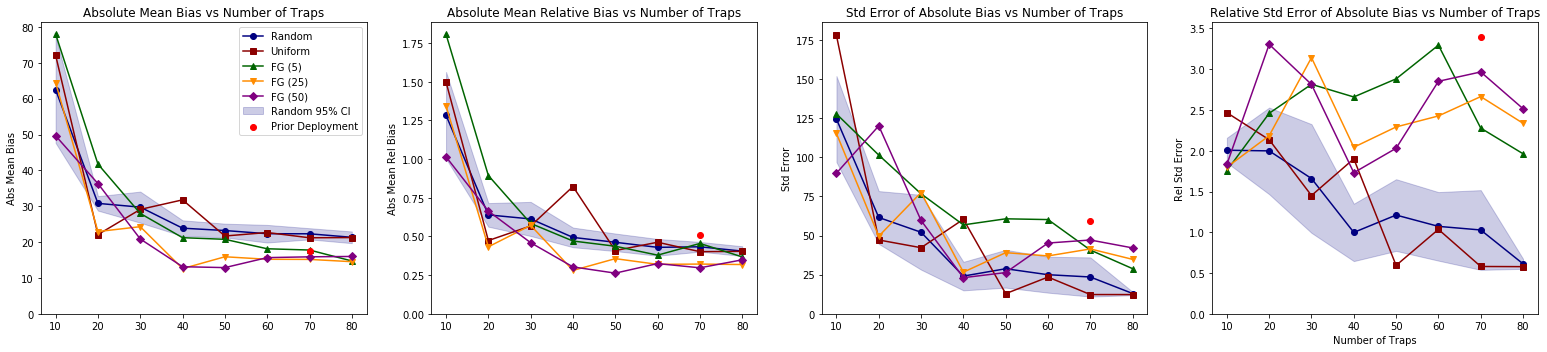

In [ ]:
############# 1km grid

random_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_1km/results'
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid'

# Base folder for Forward Greedy (FG) results
fg_base_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Forward Greedy'

trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    n = len(values)
    if n > 1:
        mean_val = np.mean(values)
        sem = np.std(values, ddof=1) / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci = t_crit * sem
        return mean_val, ci
    elif n == 1:
        return values[0], 0
    else:
        return np.nan, 0

def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    se = abs_diff.std(ddof=1)
    rse = se / mean_bias if mean_bias != 0 else np.nan
    return mean_bias, mean_rel_bias, se, rse

def process_random_data():
    # unchanged from your code ...
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        pattern = f'Random_1km_{n_traps}traps_*_1-150.csv'
        file_paths = glob.glob(os.path.join(random_folder, pattern))
        bvals, rbvals, sevals, rsevals = [], [], [], []
        for path in file_paths:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0: continue
            mb, mrb, se, rse = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
            sevals.append(se)
            rsevals.append(rse)
        mb_mean, mb_ci = calc_95ci(bvals)
        mrb_mean, mrb_ci = calc_95ci(rbvals)
        se_mean, se_ci = calc_95ci(sevals)
        rse_mean, rse_ci = calc_95ci(rsevals)
        mean_biases.append(mb_mean)
        mean_bias_cis.append(mb_ci)
        mean_rel_biases.append(mrb_mean)
        mean_rel_bias_cis.append(mrb_ci)
        ses.append(se_mean)
        se_cis.append(se_ci)
        rses.append(rse_mean)
        rse_cis.append(rse_ci)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

def process_uniform_data():
    # unchanged from your code ...
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []
    for n_traps in trap_counts:
        fname = f'U_{n_traps}A_1km_1-150.csv'
        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            mean_bias_cis.append(0)
            mean_rel_biases.append(np.nan)
            mean_rel_bias_cis.append(0)
            ses.append(np.nan)
            se_cis.append(0)
            rses.append(np.nan)
            rse_cis.append(0)
            continue
        mb, mrb, se, rse = compute_metrics(df_filtered)
        mean_biases.append(mb)
        mean_bias_cis.append(0)
        mean_rel_biases.append(mrb)
        mean_rel_bias_cis.append(0)
        ses.append(se)
        se_cis.append(0)
        rses.append(rse)
        rse_cis.append(0)
    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

def process_fg_group(fg_folders):
    """Process multiple FG folders as a group for each trap count.
    Return metrics arrays similar to random/uniform but aggregated across folders.
    """
    mean_biases, mean_bias_cis = [], []
    mean_rel_biases, mean_rel_bias_cis = [], []
    ses, se_cis = [], []
    rses, rse_cis = [], []

    for n_traps in trap_counts:
        # Collect all results across all folders for current n_traps
        all_mb, all_mrb, all_se, all_rse = [], [], [], []

        for folder in fg_folders:
            folder_path = os.path.join(fg_base_folder, folder, 'results')
            fname = f'{folder}_{n_traps}traps_1-150.csv'
            fpath = os.path.join(folder_path, fname)
            if not os.path.exists(fpath):
                continue
            df = pd.read_csv(fpath)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0:
                continue
            mb, mrb, se, rse = compute_metrics(df_filtered)
            all_mb.append(mb)
            all_mrb.append(mrb)
            all_se.append(se)
            all_rse.append(rse)

        # Calculate mean and 95% CI across the collected folder results
        mb_mean, mb_ci = calc_95ci(all_mb)
        mrb_mean, mrb_ci = calc_95ci(all_mrb)
        se_mean, se_ci = calc_95ci(all_se)
        rse_mean, rse_ci = calc_95ci(all_rse)

        mean_biases.append(mb_mean)
        mean_bias_cis.append(mb_ci)
        mean_rel_biases.append(mrb_mean)
        mean_rel_bias_cis.append(mrb_ci)
        ses.append(se_mean)
        se_cis.append(se_ci)
        rses.append(rse_mean)
        rse_cis.append(rse_ci)

    return (
        np.array(mean_biases), np.array(mean_bias_cis),
        np.array(mean_rel_biases), np.array(mean_rel_bias_cis),
        np.array(ses), np.array(se_cis),
        np.array(rses), np.array(rse_cis)
    )

random_results = process_random_data()
uniform_results = process_uniform_data()

# FG folders groups
fg5_folders = ['FG54', 'FG54-1', 'FG54-3']
fg25_folders = ['FG55', 'FG55-2', 'FG55-3']
fg50_folders = ['FG56', 'FG56-2', 'FG56-3']

fg5_results = process_fg_group(fg5_folders)
fg25_results = process_fg_group(fg25_folders)
fg50_results = process_fg_group(fg50_folders)

prior_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/results/Prior_70cams_1-150.csv'
df_prior = pd.read_csv(prior_path)
df_prior_filtered = df_prior[df_prior['N_abs_error'] <= 1000]
prior_bias, prior_rel_bias, prior_se, prior_rse = compute_metrics(df_prior_filtered)
prior_values = [prior_bias, prior_rel_bias, prior_se, prior_rse]

trap_counts_np = np.array(trap_counts)
fig, axs = plt.subplots(1, 4, figsize=(22, 5), sharex='col')
titles = [
    'Absolute Mean Bias',
    'Absolute Mean Relative Bias',
    'Std Error of Absolute Bias',
    'Relative Std Error of Absolute Bias'
]
ylabels = ['Abs Mean Bias', 'Abs Mean Rel Bias', 'Std Error', 'Rel Std Error']

# Consistent colors per data group
colors = {
    'Random': 'navy',
    'Uniform': 'darkred',
    'FG5': 'darkgreen',
    'FG25': 'darkorange',
    'FG50': 'purple',
}

for i in range(4):
    # Random line + CI
    axs[i].plot(trap_counts_np, random_results[i*2], marker='o', color=colors['Random'], label='Random')
    axs[i].fill_between(trap_counts_np,
                        np.maximum(random_results[i*2] - random_results[i*2+1], 0),
                        random_results[i*2] + random_results[i*2+1],
                        color=colors['Random'], alpha=0.2, label='Random 95% CI')

    # Uniform line (no CI)
    axs[i].plot(trap_counts_np, uniform_results[i*2], marker='s', color=colors['Uniform'], label='Uniform')

    # FG5 line (CI optional; currently commented out)
    axs[i].plot(trap_counts_np, fg5_results[i*2], marker='^', color=colors['FG5'], label='FG (5)')

    # FG25 line (CI optional; currently commented out)
    axs[i].plot(trap_counts_np, fg25_results[i*2], marker='v', color=colors['FG25'], label='FG (25)')

    # FG50 line (CI optional; currently commented out)
    axs[i].plot(trap_counts_np, fg50_results[i*2], marker='D', color=colors['FG50'], label='FG (50)')

    # Prior Deployment point
    axs[i].scatter(70, prior_values[i], color='red', label='Prior Deployment', zorder=5)

    axs[i].set_title(f'{titles[i]} vs Number of Traps')
    axs[i].set_ylabel(ylabels[i])
    axs[i].grid(False)
    axs[i].set_ylim(bottom=0)

    # Show legend only on the first plot (i == 0)
    if i == 0:
        axs[i].legend()


axs[-1].set_xlabel('Number of Traps')
plt.tight_layout()
plt.show()


### Sample Average Approximation

In [ ]:
# randomly select 10 numbers between 1 and 101 20 times in python without replacement
random_params = [np.random.choice(range(1, 102), size=10, replace=False) for _ in range(20)]
random_params

[array([ 1, 97, 68, 48, 38, 75, 94, 17, 20, 64]),
 array([82, 72, 43, 76, 93, 65, 61, 99, 62, 11]),
 array([85, 69,  2, 86, 45, 49, 81, 87, 40, 22]),
 array([90, 19, 82, 34, 86, 47, 29, 92, 71,  2]),
 array([30, 82, 42, 22, 53, 73, 28, 92, 27, 70]),
 array([42, 29, 17,  3, 84, 88, 20, 99, 90, 47]),
 array([36, 45, 88, 33,  1, 61, 29, 99, 30, 75]),
 array([76,  6, 89, 24,  7, 91, 45, 83, 48, 56]),
 array([27, 76, 97, 13, 25,  6, 12,  2, 98, 67]),
 array([44, 49, 97, 43, 85, 54,  1, 69, 56, 17]),
 array([71, 53, 16, 70,  8, 87, 28, 81, 21,  3]),
 array([28,  3, 42, 31, 15, 63, 32, 64, 21, 26]),
 array([93, 61, 92, 79, 96, 72, 53,  5, 47, 90]),
 array([36, 37, 72,  5, 42, 39, 40, 67, 51, 35]),
 array([ 53, 100,  33,  60,  72,  80,  19,  26,  15,  34]),
 array([34, 93, 79, 36, 69, 94, 22, 26, 43, 13]),
 array([96, 84, 19, 88, 72,  7, 16, 43, 50, 46]),
 array([44, 76, 43, 72, 71, 17, 27, 53, 57, 73]),
 array([ 54,  13,  61,  36,  31,  66,   8,  49, 100,  63]),
 array([66,  8, 33, 49, 26, 87

In [43]:
## loop through all files in scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/SA1-1/results and conver the csv files to dataframes
data_folder = "secr/Sample Average Approximation/SA1/SA1-4/results"

# in each dataframe for each file, look at the column 'N_abs_error'.
for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_folder, file))
        # Filter out any rows with a value in this column > 1000.
        filtered = df[df['N_abs_error'] <= 1000]
        # report the average of the remaining rows for each dataframe and print this out.
        print(f"Average N_abs_error for {file}: {filtered['N_abs_error'].mean()}")

Average N_abs_error for SA1-4_10traps_101-151.csv: 64.58724543115507
Average N_abs_error for SA1-4_20traps_101-151.csv: 82.2896884370129
